# 2ndDataGen_iGsXgBoost.ipynb — XGBoost + Greedy Sampling on Inputs and Outputs

This notebook reproduces the active learning path that combines greedy sampling in both the input and output spaces for the XGBoost surrogate model.

The selection strategy balances:
- input-space diversity (exploration)
- output-space relevance (exploitation)

The workflow includes:
- generation of the candidate pool
- hybrid greedy selection of new fluids
- incorporation of newly simulated fluids in batches of two
- preprocessing and BEP-based scaling
- iterative retraining of the XGBoost model
- performance tracking as the number of fluids increases

> **Note:** This hybrid sampling strategy represents a combined exploration–exploitation approach. This notebook is provided primarily to document the methodology and experimental workflow used in the study. Some data-loading steps depend on project-specific files not fully distributed in the public repository.

In [1]:
#Import the .py file with the functions 
import importlib
import joblib
import Functions_PumpAI as fun
from pyDOE2 import lhs
import numpy as np
importlib.reload(fun)

XGBoost version: 1.7.6
XGBoost version: 1.7.6


<module 'Functions_PumpAI' from '/Users/danielmorantes/PythonP/ua_alframework_pump/Functions_PumpAI.py'>

In [3]:
#Load the initial objetcs
intmodelxgb = joblib.load('artifacts/best_xgbintdata.pkl')
intresultsxgb = joblib.load('artifacts/results_xgbintdata.pkl')
intscalerXxgb = joblib.load('artifacts/scaler_xbf_IntTrain.pkl')
candidates_pool = joblib.load('artifacts/candidate_pool_with_mass_flow.pkl')
# Train and test data only normalized with the BEP
bepscaled_initial_trainData = joblib.load('artifacts/bepscaleddf_initialDATA.pkl')
testdata_bepscaled = joblib.load('artifacts/bepscaled_testdf.pkl')

In [4]:
#Paramters of the XGB model
feature_cols = ['rho(kg/m3)', 'k(Pa*s^n)', 'n(-)', 
                'massflow_dim']
target_cols = 'head_dim'
param_dist = {
    'learning_rate': [0.001, 0.01,0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4, 5],
    'n_estimators': [100, 200, 300, 500, 700],
    'min_child_weight': [1, 5, 10],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 0.5, 1],
    'reg_lambda': [0, 1, 5, 10]}
cv_folds = 25
n_iter = 500
val_size = 0.1

In [76]:
#List for models and scores during the training
xgb_modelsGSi = []
xgb_modelsGSi.append(intmodelxgb)
xgb_scoresGSi = []

# Greedy Sampling on inputs and outputs for XGBOOST 
- Rerun the following cells carefully due to the same excel sheet is being augmented with the selected candidates

**First Iteration**

In [16]:
#Select the 2 fluids to simulates
fluids_selected, update_pool1 = fun.greedy_sampling_inputs_outputs(intmodelxgb, bepscaled_initial_trainData, candidates_pool
                                                                  , intscalerXxgb, feature_cols)
fluids_selected 

Selected 2 new candidates:
Remaining pool size: 2998


/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


,rho(kg/m3),k(Pa*s^n),n(-),FluidType,massflow_dim
2165,1002.438140,6.563421,0.206937,PowerLaw,0.041423
2206,1002.491996,6.689992,0.366106,PowerLaw,0.165565


In [17]:
#Load the results of the simulations of the selected fluids
file_path = "/Users/danielmorantes/Downloads/DatasetFinal.xlsx"
sheet_name = "GSiXGB"
GSiraw1 = fun.load_excel_data(file_path, sheet_name)

#BEP scaling og the raw selected fluids
entireGSi1, GSi_BEPscaled1 = fun.apply_bep_scaling(GSiraw1)
GSi_BEPscaled1.info()

 Loaded data with shape: (12, 11)
 Loaded Fluids: 2
Dropped columns: ['Liquid', 'Concentration', 'Flow Rate(GPM)', 'Flow Rate[m3/h]', 'Omega(rpm)']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   LiquidNo            9 non-null      int64  
 1   rho(kg/m3)          9 non-null      float64
 2   k(Pa*s^n)           9 non-null      float64
 3   n(-)                9 non-null      float64
 4   massflow_dim        9 non-null      float64
 5   torque_dim          9 non-null      float64
 6   hydraulicpower_dim  9 non-null      float64
 7   breakpower_dim      9 non-null      float64
 8   eff_dim             9 non-null      float64
 9   head_dim            9 non-null      float64
dtypes: float64(9), int64(1)
memory usage: 852.0 bytes


In [18]:
#Add to the original train set the GSi generated fluids 2 by 2
train_sets, list_fluids1 = fun.loop_add_fluids_in_order(bepscaled_initial_trainData, GSi_BEPscaled1)
train_sets[0] #Look for the first train set (Original + 2 fluids)

Iteration 1: New training set includes 35 unique fluids


,LiquidNo,rho(kg/m3),k(Pa*s^n),n(-),massflow_dim,torque_dim,hydraulicpower_dim,breakpower_dim,eff_dim,head_dim
0,0,997.000000,0.001000,1.000000,0.000000,0.679632,0.000000,0.679633,0.000000,1.290569
1,0,997.000000,0.001000,1.000000,0.250000,0.724184,0.303160,0.724184,0.418623,1.212641
2,0,997.000000,0.001000,1.000000,0.500000,0.812492,0.582448,0.812492,0.716867,1.164897
3,0,997.000000,0.001000,1.000000,0.750000,0.913659,0.824483,0.913659,0.902397,1.099311
4,0,997.000000,0.001000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...
145,34,1002.491996,6.689992,0.366196,0.139613,1.000000,1.000000,1.000000,0.237890,1.239587
146,34,1002.491996,6.689992,0.366196,0.333333,1.000000,1.000000,1.000000,0.513634,1.205862
147,34,1002.491996,6.689992,0.366196,0.666667,1.000000,1.000000,1.000000,0.313929,0.376747
148,34,1002.491996,6.689992,0.366196,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Split completed: 133 train samples, 17 validation samples.
Test set size: 57 samples (FIXED TEST SET).
Features and target scaled.
Fitting 25 folds for each of 500 candidates, totalling 12500 fits


/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/numpy/ma/core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


mse_train: 0.0776
r2_train: 0.9224
mse_val: 0.5021
r2_val: 0.7235
mse_test: 0.1009
r2_test: 0.7508
Best hyperparameters: {'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha': 0.5, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.2, 'colsample_bytree': 1.0}


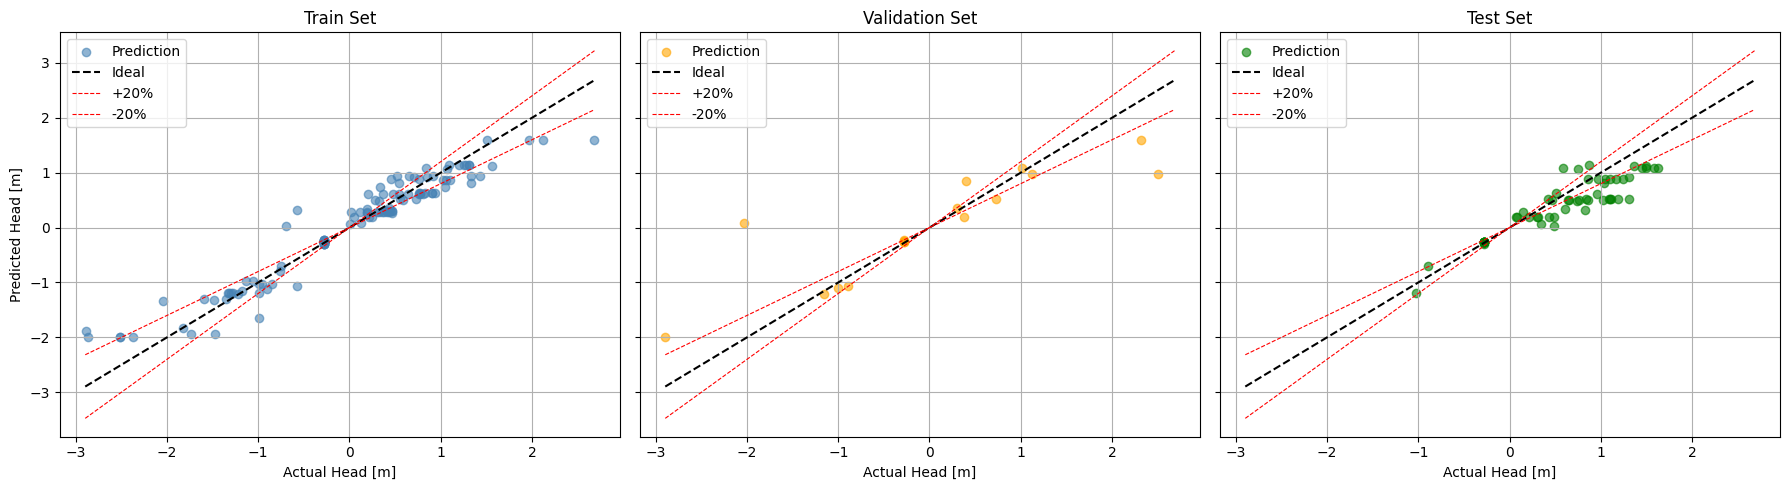

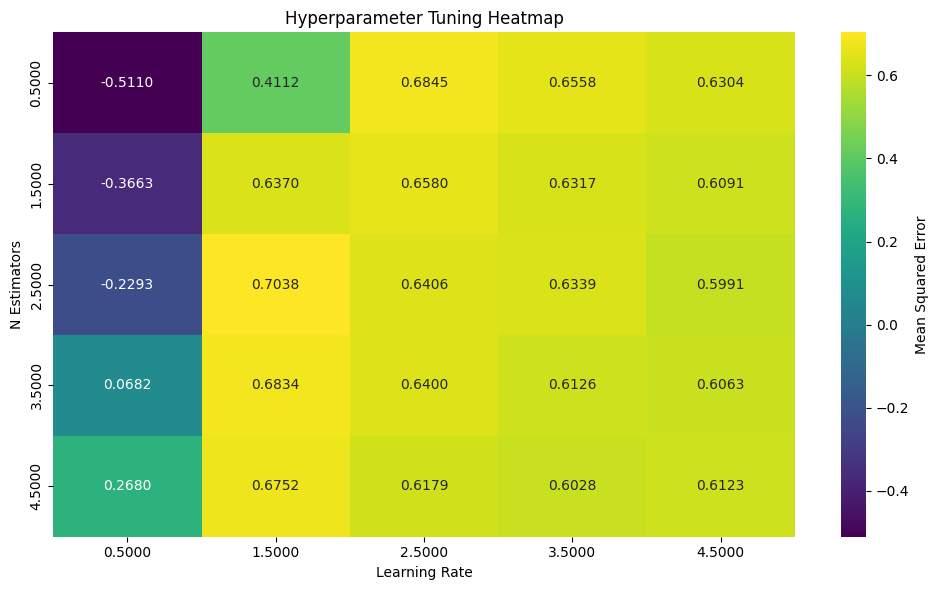

In [19]:
#Split and scaled new train set
Xtrain_scaled1, Xval_scaled1, Xtest_scaled1, ytrain_scaled1, yval_scaled1, ytest_scaled1, scalerx1, scalery1 = fun.splitandscale_byfluid(train_sets[0]
                                                                                                                                         , testdata_bepscaled, feature_cols, target_cols, val_size)

#Train XGBoost new train set (+2 fluids)
xgb_model1, xgb_score1 = fun.xgboost_with_cv(Xtrain_scaled1, ytrain_scaled1, Xval_scaled1, yval_scaled1,
                                             Xtest_scaled1, ytest_scaled1, param_dist, n_iter, cv_folds, img_name='no')
xgb_modelsGSi.append(xgb_model1)
xgb_scoresGSi.append(xgb_score1)

**Second Iterarion**

In [20]:
#Select the 2 fluids to simulate 
fluids_selected, update_pool2 = fun.greedy_sampling_inputs_outputs(xgb_model1, train_sets[0], update_pool1
                                                                  , scalerx1, feature_cols)
fluids_selected 

Selected 2 new candidates:
Remaining pool size: 2996


/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


,rho(kg/m3),k(Pa*s^n),n(-),FluidType,massflow_dim
2061,1016.088500,10.910142,0.555898,PowerLaw,0.266414
2670,1004.841961,10.632639,0.548262,PowerLaw,0.287441


In [21]:
#Load the results of the simulations of the selected fluids
file_path = "/Users/danielmorantes/Downloads/DatasetFinal.xlsx"
sheet_name = "GSiXGB"
GSiraw2 = fun.load_excel_data(file_path, sheet_name)

#BEP scaling og the raw selected fluids
entireGSi2, GSi_BEPscaled2 = fun.apply_bep_scaling(GSiraw2)
GSi_BEPscaled2.info()

 Loaded data with shape: (24, 11)
 Loaded Fluids: 4
Dropped columns: ['Liquid', 'Concentration', 'Flow Rate(GPM)', 'Flow Rate[m3/h]', 'Omega(rpm)']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   LiquidNo            15 non-null     int64  
 1   rho(kg/m3)          15 non-null     float64
 2   k(Pa*s^n)           15 non-null     float64
 3   n(-)                15 non-null     float64
 4   massflow_dim        15 non-null     float64
 5   torque_dim          15 non-null     float64
 6   hydraulicpower_dim  15 non-null     float64
 7   breakpower_dim      15 non-null     float64
 8   eff_dim             15 non-null     float64
 9   head_dim            15 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 1.3 KB


In [22]:
#Add to the original train set the GSi generated fluids 2 by 2
train_sets, list_fluids2 = fun.loop_add_fluids_in_order(bepscaled_initial_trainData, GSi_BEPscaled2)
train_sets[1] #Look for the second train set (Original + 4 fluids)

Iteration 1: New training set includes 35 unique fluids
Iteration 2: New training set includes 37 unique fluids


,LiquidNo,rho(kg/m3),k(Pa*s^n),n(-),massflow_dim,torque_dim,hydraulicpower_dim,breakpower_dim,eff_dim,head_dim
0,0,997.000000,0.001000,1.000000,0.000000,0.679632,0.000000,0.679633,0.000000,1.290569
1,0,997.000000,0.001000,1.000000,0.250000,0.724184,0.303160,0.724184,0.418623,1.212641
2,0,997.000000,0.001000,1.000000,0.500000,0.812492,0.582448,0.812492,0.716867,1.164897
3,0,997.000000,0.001000,1.000000,0.750000,0.913659,0.824483,0.913659,0.902397,1.099311
4,0,997.000000,0.001000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...
151,35,1016.088500,10.910142,0.555898,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
152,35,1016.088500,10.910142,0.555898,1.500000,1.000000,1.000000,1.000000,0.432542,0.315962
153,36,1004.841961,10.632639,0.548262,0.241818,1.000000,1.000000,1.000000,0.689051,2.317430
154,36,1004.841961,10.632639,0.548262,0.333333,1.000000,1.000000,1.000000,0.739854,1.730914


Split completed: 141 train samples, 15 validation samples.
Test set size: 57 samples (FIXED TEST SET).
Features and target scaled.
Fitting 25 folds for each of 500 candidates, totalling 12500 fits


/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/numpy/ma/core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


mse_train: 0.2318
r2_train: 0.7682
mse_val: 0.5281
r2_val: 0.6962
mse_test: 0.0579
r2_test: 0.8315
Best hyperparameters: {'subsample': 0.6, 'reg_lambda': 10, 'reg_alpha': 1, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 1.0}


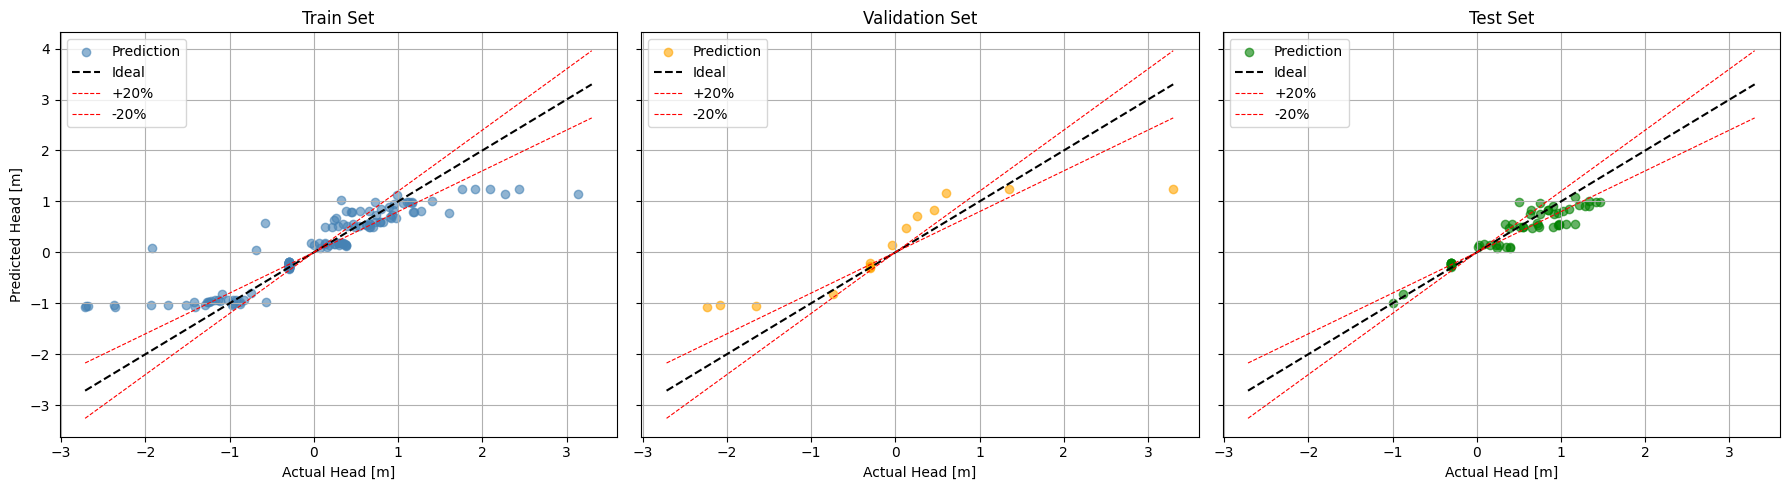

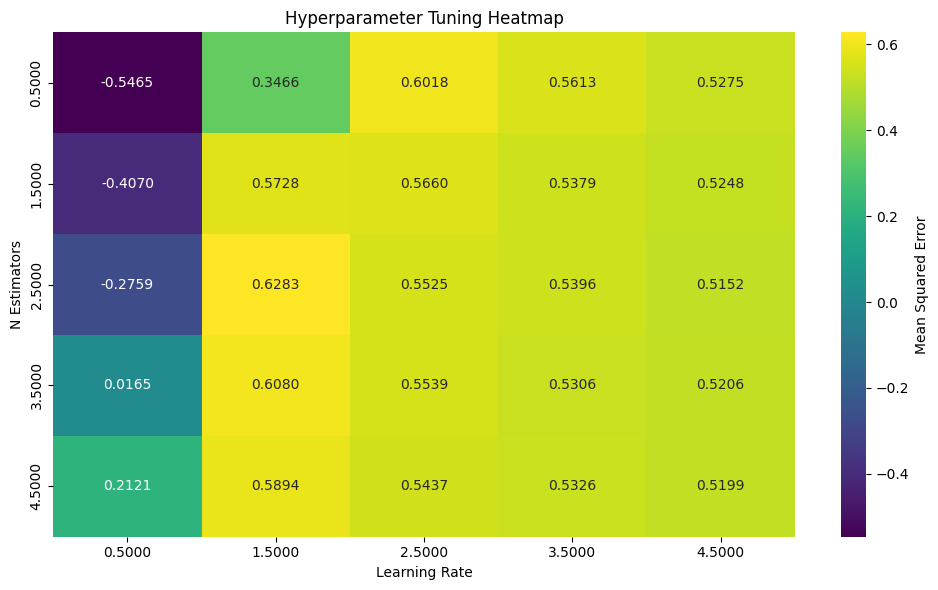

In [23]:
#Split and scaled new train set
Xtrain_scaled2, Xval_scaled2, Xtest_scaled2, ytrain_scaled2, yval_scaled2, ytest_scaled2, scalerx2, scalery2 = fun.splitandscale_byfluid(train_sets[1]
                                                                                                                                         , testdata_bepscaled, feature_cols, target_cols, val_size)

#Train XGBoost new train set (+2 fluids)
xgb_model2, xgb_score2 = fun.xgboost_with_cv(Xtrain_scaled2, ytrain_scaled2, Xval_scaled2, yval_scaled2,
                                             Xtest_scaled2, ytest_scaled2, param_dist, n_iter, cv_folds, img_name='no')
xgb_modelsGSi.append(xgb_model2)
xgb_scoresGSi.append(xgb_score2)

**Third Iteration**

In [24]:
#Select the 2 fluids to simulate 
fluids_selected, update_pool3 = fun.greedy_sampling_inputs_outputs(xgb_model2, train_sets[1], update_pool2
                                                                  , scalerx2, feature_cols)
fluids_selected 

Selected 2 new candidates:
Remaining pool size: 2994


/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


,rho(kg/m3),k(Pa*s^n),n(-),FluidType,massflow_dim
1542,812.371746,0.023128,1.0,BlackOil,1.159953
1581,740.172267,0.004767,1.0,BlackOil,1.161386


In [25]:
#Load the results of the simulations of the selected fluids
file_path = "/Users/danielmorantes/Downloads/DatasetFinal.xlsx"
sheet_name = "GSiXGB"
GSiraw3 = fun.load_excel_data(file_path, sheet_name)

#BEP scaling og the raw selected fluids
entireGSi3, GSi_BEPscaled3 = fun.apply_bep_scaling(GSiraw3)
GSi_BEPscaled3.info()

 Loaded data with shape: (36, 11)
 Loaded Fluids: 6
Dropped columns: ['Liquid', 'Concentration', 'Flow Rate(GPM)', 'Flow Rate[m3/h]', 'Omega(rpm)']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   LiquidNo            27 non-null     int64  
 1   rho(kg/m3)          27 non-null     float64
 2   k(Pa*s^n)           27 non-null     float64
 3   n(-)                27 non-null     float64
 4   massflow_dim        27 non-null     float64
 5   torque_dim          27 non-null     float64
 6   hydraulicpower_dim  27 non-null     float64
 7   breakpower_dim      27 non-null     float64
 8   eff_dim             27 non-null     float64
 9   head_dim            27 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 2.2 KB


In [26]:
#Add to the original train set the GSi generated fluids 2 by 2
train_sets, list_fluids3 = fun.loop_add_fluids_in_order(bepscaled_initial_trainData, GSi_BEPscaled3)
train_sets[2] #Look for the third train set (Original + 6 fluids)

Iteration 1: New training set includes 35 unique fluids
Iteration 2: New training set includes 37 unique fluids
Iteration 3: New training set includes 39 unique fluids


,LiquidNo,rho(kg/m3),k(Pa*s^n),n(-),massflow_dim,torque_dim,hydraulicpower_dim,breakpower_dim,eff_dim,head_dim
0,0,997.000000,0.001000,1.0,0.000000,0.679632,0.000000,0.679633,0.000000,1.290569
1,0,997.000000,0.001000,1.0,0.250000,0.724184,0.303160,0.724184,0.418623,1.212641
2,0,997.000000,0.001000,1.0,0.500000,0.812492,0.582448,0.812492,0.716867,1.164897
3,0,997.000000,0.001000,1.0,0.750000,0.913659,0.824483,0.913659,0.902397,1.099311
4,0,997.000000,0.001000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...
163,38,740.172267,0.004767,1.0,0.333333,1.000000,1.000000,1.000000,0.521371,1.229665
164,38,740.172267,0.004767,1.0,0.666667,1.000000,1.000000,1.000000,0.851417,1.146157
165,38,740.172267,0.004767,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
166,38,740.172267,0.004767,1.0,1.326419,1.000000,1.000000,1.000000,0.968088,0.773301


Split completed: 146 train samples, 22 validation samples.
Test set size: 57 samples (FIXED TEST SET).
Features and target scaled.
Fitting 25 folds for each of 500 candidates, totalling 12500 fits


/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/numpy/ma/core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


mse_train: 0.0876
r2_train: 0.9124
mse_val: 0.0276
r2_val: 0.9113
mse_test: 0.0569
r2_test: 0.8135
Best hyperparameters: {'subsample': 1.0, 'reg_lambda': 0, 'reg_alpha': 1, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.2, 'gamma': 0.2, 'colsample_bytree': 1.0}


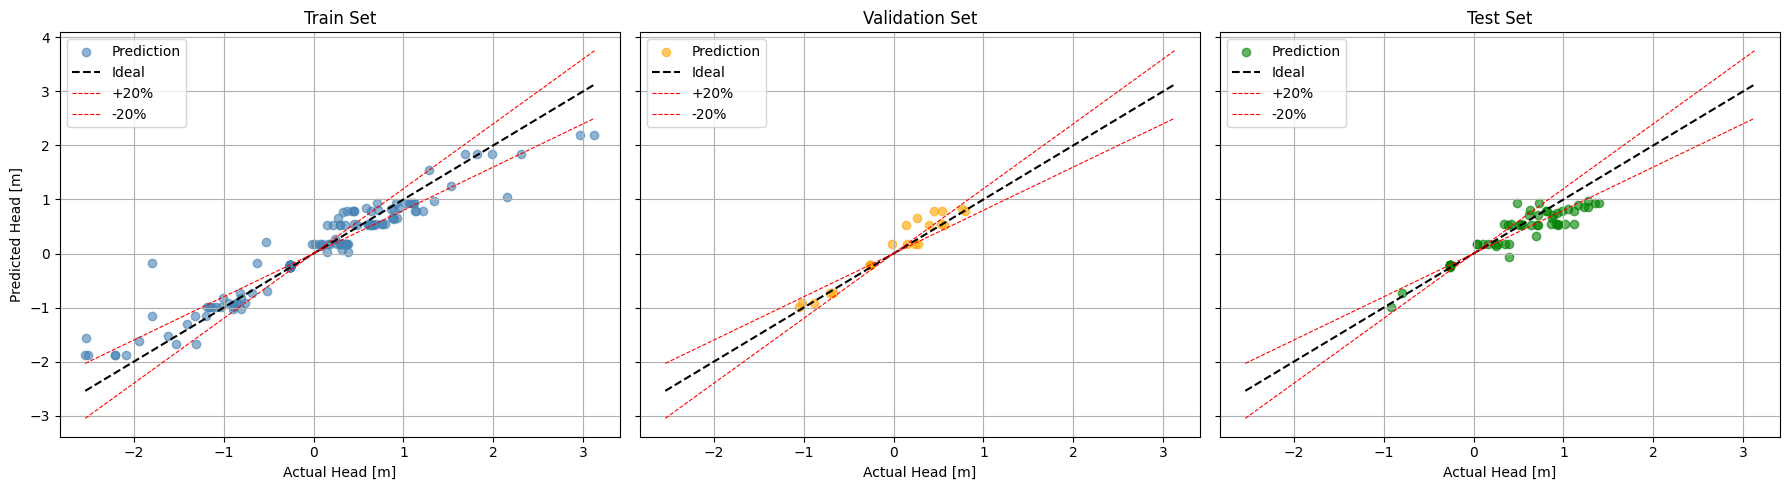

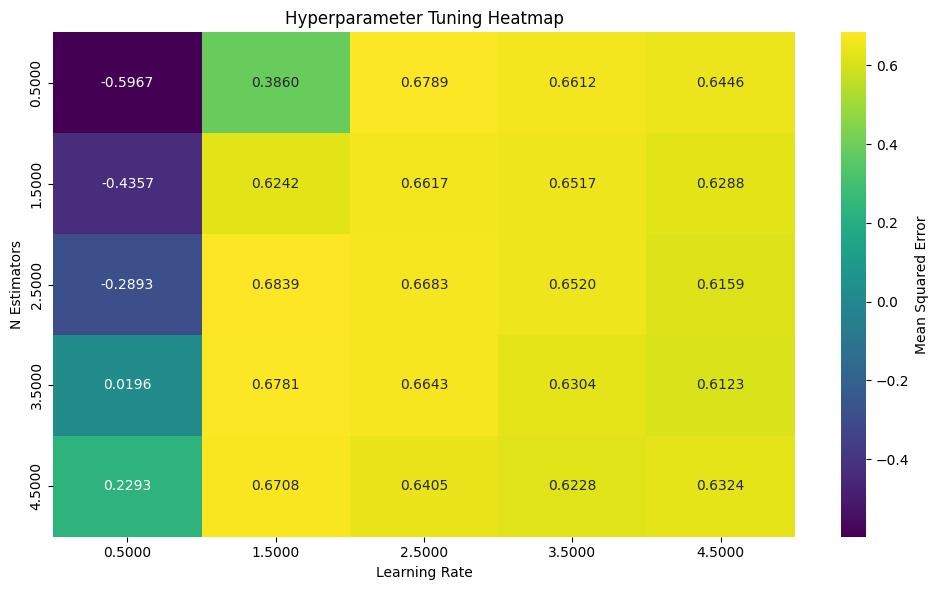

In [27]:
#Split and scaled new train set
Xtrain_scaled3, Xval_scaled3, Xtest_scaled3, ytrain_scaled3, yval_scaled3, ytest_scaled3, scalerx3, scalery3 = fun.splitandscale_byfluid(train_sets[2]
                                                                                                                                         , testdata_bepscaled, feature_cols, target_cols, val_size)

#Train XGBoost new train set (+2 fluids)
xgb_model3, xgb_score3 = fun.xgboost_with_cv(Xtrain_scaled3, ytrain_scaled3, Xval_scaled3, yval_scaled3,
                                             Xtest_scaled3, ytest_scaled3, param_dist, n_iter, cv_folds, img_name='no')
xgb_modelsGSi.append(xgb_model3)
xgb_scoresGSi.append(xgb_score3)

**Fourth Iteration**

In [28]:
#Select the 2 fluids to simulate 
fluids_selected, update_pool4 = fun.greedy_sampling_inputs_outputs(xgb_model3, train_sets[2], update_pool3
                                                                  , scalerx3, feature_cols)
fluids_selected 

Selected 2 new candidates:
Remaining pool size: 2992


/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


,rho(kg/m3),k(Pa*s^n),n(-),FluidType,massflow_dim
2603,1010.238397,10.187365,0.255998,PowerLaw,0.178468
2446,1010.292737,9.375158,0.205671,PowerLaw,0.213680


In [29]:
#Load the results of the simulations of the selected fluids
file_path = "/Users/danielmorantes/Downloads/DatasetFinal.xlsx"
sheet_name = "GSiXGB"
GSiraw4 = fun.load_excel_data(file_path, sheet_name)

#BEP scaling og the raw selected fluids
entireGSi4, GSi_BEPscaled4 = fun.apply_bep_scaling(GSiraw4)
GSi_BEPscaled4.info()

 Loaded data with shape: (48, 11)
 Loaded Fluids: 8
Dropped columns: ['Liquid', 'Concentration', 'Flow Rate(GPM)', 'Flow Rate[m3/h]', 'Omega(rpm)']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   LiquidNo            37 non-null     int64  
 1   rho(kg/m3)          37 non-null     float64
 2   k(Pa*s^n)           37 non-null     float64
 3   n(-)                37 non-null     float64
 4   massflow_dim        37 non-null     float64
 5   torque_dim          37 non-null     float64
 6   hydraulicpower_dim  37 non-null     float64
 7   breakpower_dim      37 non-null     float64
 8   eff_dim             37 non-null     float64
 9   head_dim            37 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 3.0 KB


In [30]:
#Add to the original train set the GSi generated fluids 2 by 2
train_sets, list_fluids4 = fun.loop_add_fluids_in_order(bepscaled_initial_trainData, GSi_BEPscaled4)
train_sets[3] #Look for the Fourth train set (Original + 8 fluids)

Iteration 1: New training set includes 35 unique fluids
Iteration 2: New training set includes 37 unique fluids
Iteration 3: New training set includes 39 unique fluids
Iteration 4: New training set includes 41 unique fluids


,LiquidNo,rho(kg/m3),k(Pa*s^n),n(-),massflow_dim,torque_dim,hydraulicpower_dim,breakpower_dim,eff_dim,head_dim
0,0,997.000000,0.001000,1.000000,0.000000,0.679632,0.000000,0.679633,0.000000,1.290569
1,0,997.000000,0.001000,1.000000,0.250000,0.724184,0.303160,0.724184,0.418623,1.212641
2,0,997.000000,0.001000,1.000000,0.500000,0.812492,0.582448,0.812492,0.716867,1.164897
3,0,997.000000,0.001000,1.000000,0.750000,0.913659,0.824483,0.913659,0.902397,1.099311
4,0,997.000000,0.001000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...
173,40,1010.292737,9.375158,0.205671,0.134096,1.000000,1.000000,1.000000,0.297386,1.528418
174,40,1010.292737,9.375158,0.205671,0.250000,1.000000,1.000000,1.000000,0.366553,1.128908
175,40,1010.292737,9.375158,0.205671,0.500000,1.000000,1.000000,1.000000,0.819955,1.361189
176,40,1010.292737,9.375158,0.205671,0.750000,1.000000,1.000000,1.000000,0.982387,1.221485


Split completed: 153 train samples, 25 validation samples.
Test set size: 57 samples (FIXED TEST SET).
Features and target scaled.
Fitting 25 folds for each of 500 candidates, totalling 12500 fits
mse_train: 0.0950
r2_train: 0.9050
mse_val: 0.1645
r2_val: 0.8249
mse_test: 0.1056
r2_test: 0.6921
Best hyperparameters: {'subsample': 1.0, 'reg_lambda': 0, 'reg_alpha': 1, 'n_estimators': 100, 'min_child_weight': 10, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}


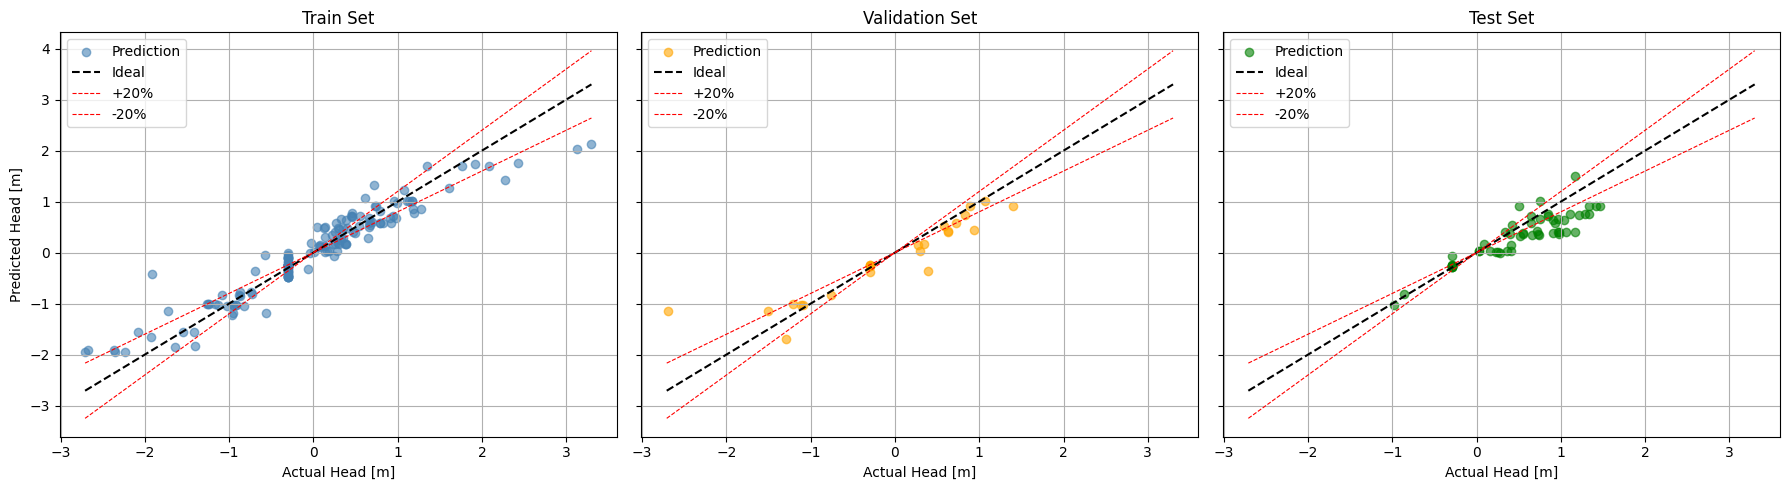

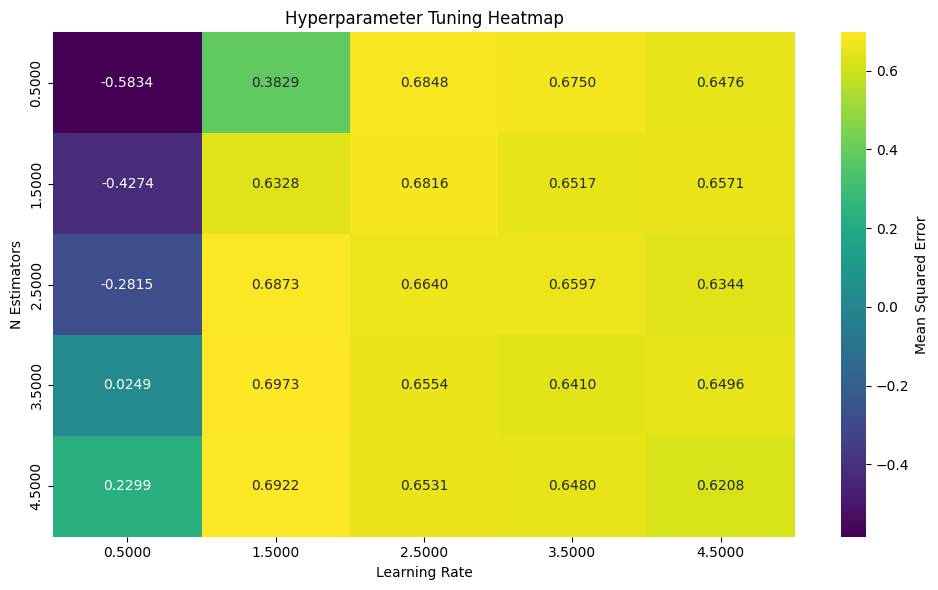

In [31]:
#Split and scaled new train set
Xtrain_scaled4, Xval_scaled4, Xtest_scaled4, ytrain_scaled4, yval_scaled4, ytest_scaled4, scalerx4, scalery4 = fun.splitandscale_byfluid(train_sets[3]
                                                                                                                                         , testdata_bepscaled, feature_cols, target_cols, val_size)

#Train XGBoost new train set (+2 fluids)
xgb_model4, xgb_score4 = fun.xgboost_with_cv(Xtrain_scaled4, ytrain_scaled4, Xval_scaled4, yval_scaled4,
                                             Xtest_scaled4, ytest_scaled4, param_dist, n_iter, cv_folds, img_name='no')
xgb_modelsGSi.append(xgb_model4)
xgb_scoresGSi.append(xgb_score4)

**Fifth Iteration**

In [32]:
#Select the 2 fluids to simulate 
fluids_selected, update_pool5 = fun.greedy_sampling_inputs_outputs(xgb_model4, train_sets[3], update_pool4
                                                                  , scalerx4, feature_cols)
fluids_selected 

Selected 2 new candidates:
Remaining pool size: 2990


/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


,rho(kg/m3),k(Pa*s^n),n(-),FluidType,massflow_dim
2115,1016.467799,1.621666,0.28953,PowerLaw,1.246818
2687,1010.513112,0.194559,0.29222,PowerLaw,1.281161


In [33]:
#Load the results of the simulations of the selected fluids
file_path = "/Users/danielmorantes/Downloads/DatasetFinal.xlsx"
sheet_name = "GSiXGB"
GSiraw5 = fun.load_excel_data(file_path, sheet_name)

#BEP scaling og the raw selected fluids
entireGSi5, GSi_BEPscaled5 = fun.apply_bep_scaling(GSiraw5)
GSi_BEPscaled5.info()

 Loaded data with shape: (60, 11)
 Loaded Fluids: 10
Dropped columns: ['Liquid', 'Concentration', 'Flow Rate(GPM)', 'Flow Rate[m3/h]', 'Omega(rpm)']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   LiquidNo            44 non-null     int64  
 1   rho(kg/m3)          44 non-null     float64
 2   k(Pa*s^n)           44 non-null     float64
 3   n(-)                44 non-null     float64
 4   massflow_dim        44 non-null     float64
 5   torque_dim          44 non-null     float64
 6   hydraulicpower_dim  44 non-null     float64
 7   breakpower_dim      44 non-null     float64
 8   eff_dim             44 non-null     float64
 9   head_dim            44 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 3.6 KB


In [34]:
#Add to the original train set the GSi generated fluids 2 by 2
train_sets, list_fluids5 = fun.loop_add_fluids_in_order(bepscaled_initial_trainData, GSi_BEPscaled5)
train_sets[4] #Look for the fifth train set (Original + 10 fluids)

Iteration 1: New training set includes 35 unique fluids
Iteration 2: New training set includes 37 unique fluids
Iteration 3: New training set includes 39 unique fluids
Iteration 4: New training set includes 41 unique fluids
Iteration 5: New training set includes 43 unique fluids


,LiquidNo,rho(kg/m3),k(Pa*s^n),n(-),massflow_dim,torque_dim,hydraulicpower_dim,breakpower_dim,eff_dim,head_dim
0,0,997.000000,0.001000,1.00000,0.000000,0.679632,0.000000,0.679633,0.000000,1.290569
1,0,997.000000,0.001000,1.00000,0.250000,0.724184,0.303160,0.724184,0.418623,1.212641
2,0,997.000000,0.001000,1.00000,0.500000,0.812492,0.582448,0.812492,0.716867,1.164897
3,0,997.000000,0.001000,1.00000,0.750000,0.913659,0.824483,0.913659,0.902397,1.099311
4,0,997.000000,0.001000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...
180,41,1016.467799,1.621666,0.28953,0.750000,1.000000,1.000000,1.000000,0.988935,1.218978
181,41,1016.467799,1.621666,0.28953,0.777692,1.000000,1.000000,1.000000,0.983185,1.195087
182,41,1016.467799,1.621666,0.28953,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
183,42,1010.513112,0.194559,0.29222,0.803822,1.000000,1.000000,1.000000,0.548578,0.595181


Split completed: 160 train samples, 25 validation samples.
Test set size: 57 samples (FIXED TEST SET).
Features and target scaled.
Fitting 25 folds for each of 500 candidates, totalling 12500 fits
mse_train: 0.1587
r2_train: 0.8413
mse_val: 0.1566
r2_val: 0.8266
mse_test: 0.1047
r2_test: 0.6973
Best hyperparameters: {'subsample': 0.6, 'reg_lambda': 10, 'reg_alpha': 0.5, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 1.0}


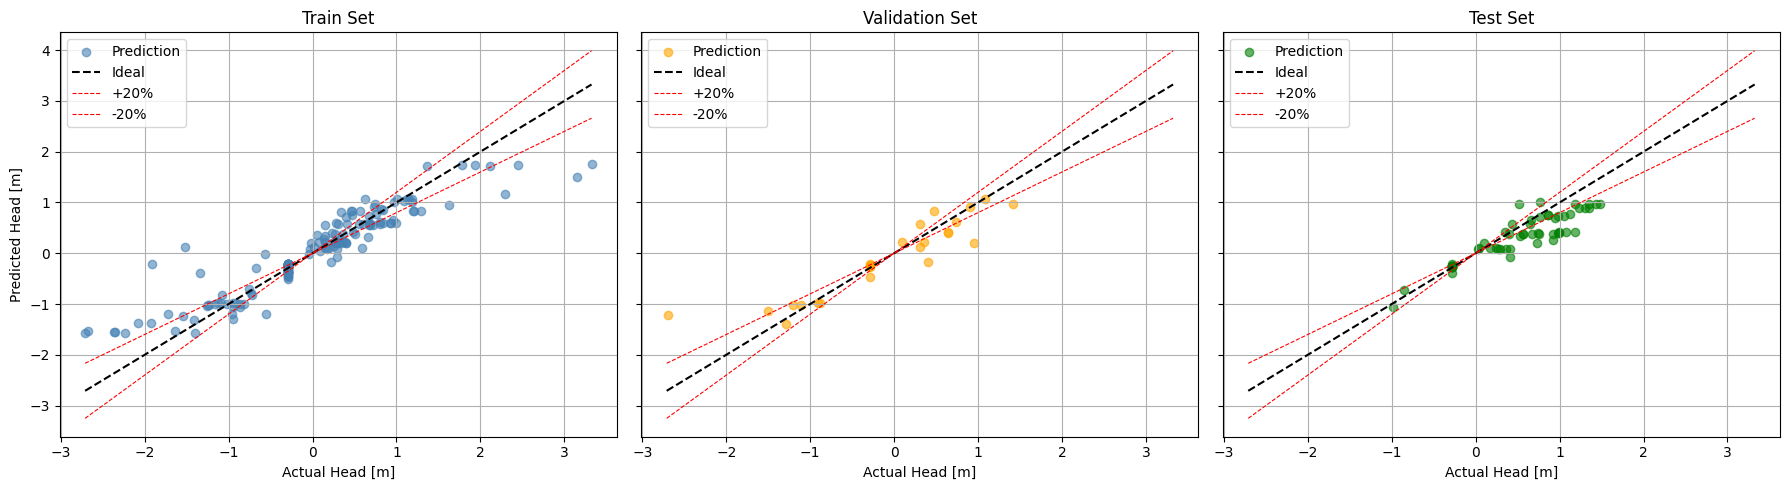

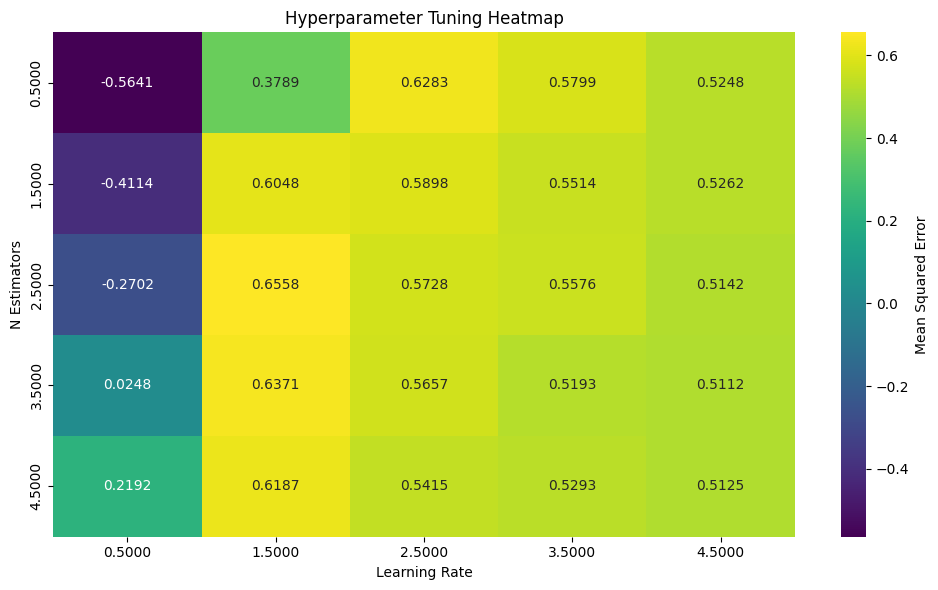

In [35]:
#Split and scaled new train set
Xtrain_scaled5, Xval_scaled5, Xtest_scaled5, ytrain_scaled5, yval_scaled5, ytest_scaled5, scalerx5, scalery5 = fun.splitandscale_byfluid(train_sets[4]
                                                                                                                                         , testdata_bepscaled, feature_cols, target_cols, val_size)

#Train XGBoost new train set (+2 fluids)
xgb_model5, xgb_score5 = fun.xgboost_with_cv(Xtrain_scaled5, ytrain_scaled5, Xval_scaled5, yval_scaled5,
                                             Xtest_scaled5, ytest_scaled5, param_dist, n_iter, cv_folds, img_name='no')
xgb_modelsGSi.append(xgb_model5)
xgb_scoresGSi.append(xgb_score5)

**Sixth Iteration**

In [36]:
#Select the 2 fluids to simulate 
fluids_selected, update_pool6 = fun.greedy_sampling_inputs_outputs(xgb_model5, train_sets[4], update_pool5
                                                                  , scalerx5, feature_cols)
fluids_selected 

Selected 2 new candidates:
Remaining pool size: 2988


/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


,rho(kg/m3),k(Pa*s^n),n(-),FluidType,massflow_dim
2515,1016.664174,10.715973,0.318667,PowerLaw,0.226138
2930,1017.568507,3.829079,0.478021,PowerLaw,1.595359


In [37]:
#Load the results of the simulations of the selected fluids
file_path = "/Users/danielmorantes/Downloads/DatasetFinal.xlsx"
sheet_name = "GSiXGB"
GSiraw6 = fun.load_excel_data(file_path, sheet_name)

#BEP scaling og the raw selected fluids
entireGSi6, GSi_BEPscaled6 = fun.apply_bep_scaling(GSiraw6)
GSi_BEPscaled6.info()

 Loaded data with shape: (72, 11)
 Loaded Fluids: 12
Dropped columns: ['Liquid', 'Concentration', 'Flow Rate(GPM)', 'Flow Rate[m3/h]', 'Omega(rpm)']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   LiquidNo            53 non-null     int64  
 1   rho(kg/m3)          53 non-null     float64
 2   k(Pa*s^n)           53 non-null     float64
 3   n(-)                53 non-null     float64
 4   massflow_dim        53 non-null     float64
 5   torque_dim          53 non-null     float64
 6   hydraulicpower_dim  53 non-null     float64
 7   breakpower_dim      53 non-null     float64
 8   eff_dim             53 non-null     float64
 9   head_dim            53 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 4.3 KB


In [38]:
#Add to the original train set the GSi generated fluids 2 by 2
train_sets, list_fluids6 = fun.loop_add_fluids_in_order(bepscaled_initial_trainData, GSi_BEPscaled6)
train_sets[5] #Look for the sixth train set (Original + 12 fluids)

Iteration 1: New training set includes 35 unique fluids
Iteration 2: New training set includes 37 unique fluids
Iteration 3: New training set includes 39 unique fluids
Iteration 4: New training set includes 41 unique fluids
Iteration 5: New training set includes 43 unique fluids
Iteration 6: New training set includes 45 unique fluids


,LiquidNo,rho(kg/m3),k(Pa*s^n),n(-),massflow_dim,torque_dim,hydraulicpower_dim,breakpower_dim,eff_dim,head_dim
0,0,997.000000,0.001000,1.000000,0.000000,0.679632,0.000000,0.679633,0.000000,1.290569
1,0,997.000000,0.001000,1.000000,0.250000,0.724184,0.303160,0.724184,0.418623,1.212641
2,0,997.000000,0.001000,1.000000,0.500000,0.812492,0.582448,0.812492,0.716867,1.164897
3,0,997.000000,0.001000,1.000000,0.750000,0.913659,0.824483,0.913659,0.902397,1.099311
4,0,997.000000,0.001000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...
189,44,1017.568507,3.829079,0.478021,0.333333,1.000000,1.000000,1.000000,0.544625,1.316730
190,44,1017.568507,3.829079,0.478021,0.666667,1.000000,1.000000,1.000000,0.878883,1.190187
191,44,1017.568507,3.829079,0.478021,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
192,44,1017.568507,3.829079,0.478021,1.325353,1.000000,1.000000,1.000000,0.522903,0.378571


Split completed: 170 train samples, 24 validation samples.
Test set size: 57 samples (FIXED TEST SET).
Features and target scaled.
Fitting 25 folds for each of 500 candidates, totalling 12500 fits
mse_train: 0.1775
r2_train: 0.8225
mse_val: 0.0555
r2_val: 0.9139
mse_test: 0.0728
r2_test: 0.7858
Best hyperparameters: {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 1.0}


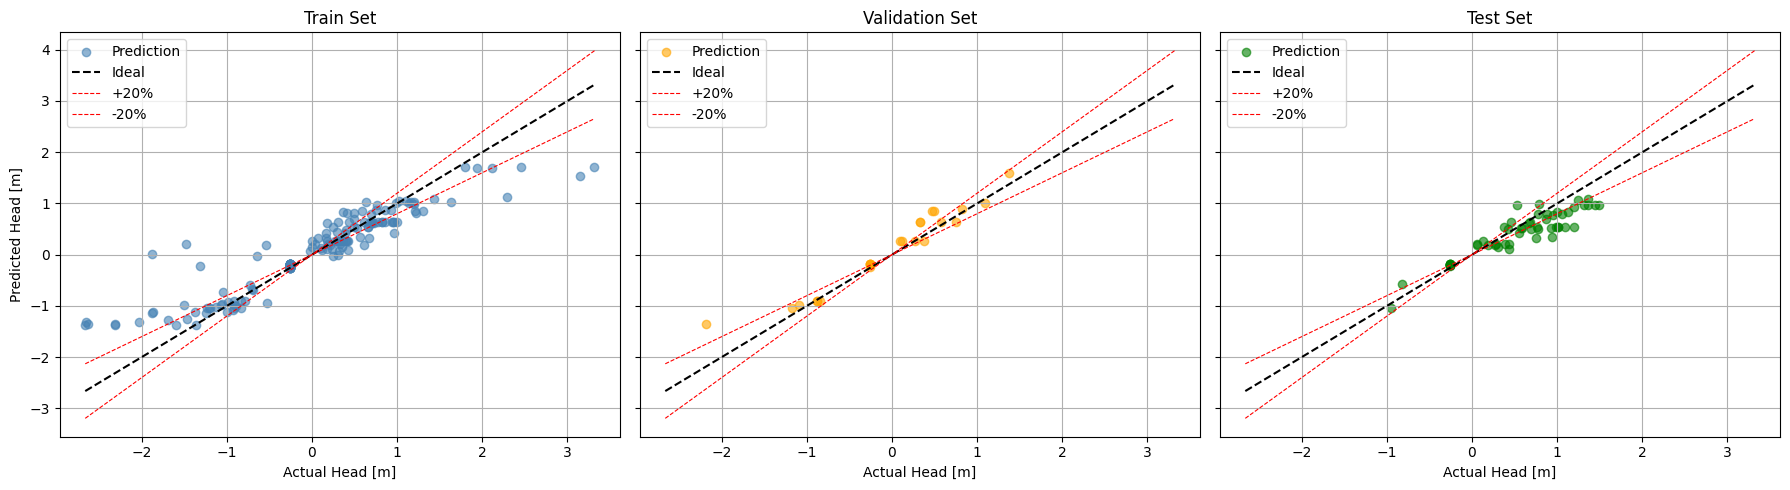

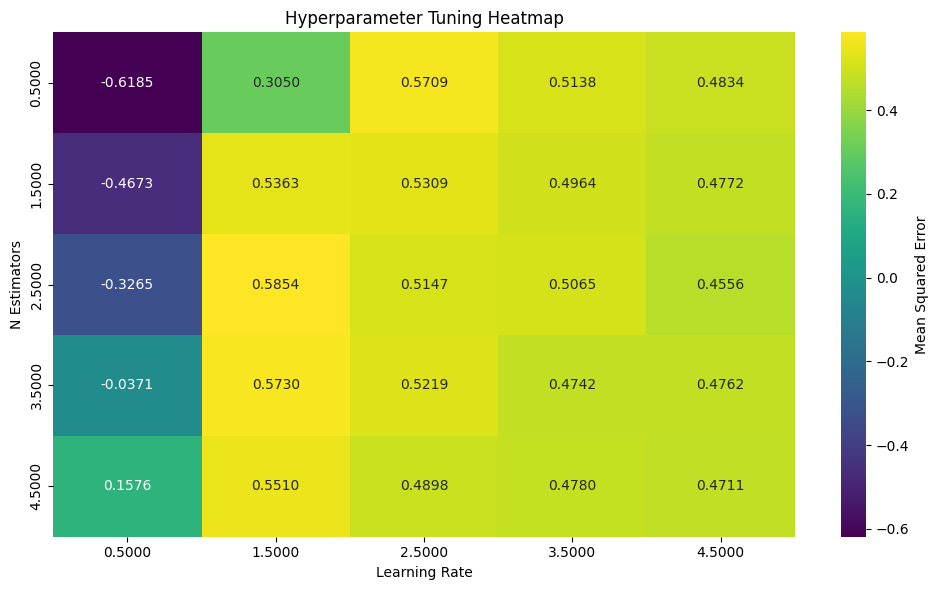

In [39]:
#Split and scaled new train set
Xtrain_scaled6, Xval_scaled6, Xtest_scaled6, ytrain_scaled6, yval_scaled6, ytest_scaled6, scalerx6, scalery6 = fun.splitandscale_byfluid(train_sets[5]
                                                                                                                                         , testdata_bepscaled, feature_cols, target_cols, val_size)

#Train XGBoost new train set (+2 fluids)
xgb_model6, xgb_score6 = fun.xgboost_with_cv(Xtrain_scaled6, ytrain_scaled6, Xval_scaled6, yval_scaled6,
                                             Xtest_scaled6, ytest_scaled6, param_dist, n_iter, cv_folds, img_name='no')
xgb_modelsGSi.append(xgb_model6)
xgb_scoresGSi.append(xgb_score6)

**Seventh Iteration**

In [40]:
#Select the 2 fluids to simulate 
fluids_selected, update_pool7 = fun.greedy_sampling_inputs_outputs(xgb_model6, train_sets[5], update_pool6
                                                                  , scalerx6, feature_cols)
fluids_selected 

Selected 2 new candidates:
Remaining pool size: 2986


/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


,rho(kg/m3),k(Pa*s^n),n(-),FluidType,massflow_dim
861,794.987781,0.016611,1.0,Newtonian,1.119750
207,845.569606,0.006786,1.0,Newtonian,1.119208


In [41]:
#Load the results of the simulations of the selected fluids
file_path = "/Users/danielmorantes/Downloads/DatasetFinal.xlsx"
sheet_name = "GSiXGB"
GSiraw7 = fun.load_excel_data(file_path, sheet_name)

#BEP scaling og the raw selected fluids
entireGSi7, GSi_BEPscaled7 = fun.apply_bep_scaling(GSiraw7)
GSi_BEPscaled7.info()

 Loaded data with shape: (84, 11)
 Loaded Fluids: 14
Dropped columns: ['Liquid', 'Concentration', 'Flow Rate(GPM)', 'Flow Rate[m3/h]', 'Omega(rpm)']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   LiquidNo            65 non-null     int64  
 1   rho(kg/m3)          65 non-null     float64
 2   k(Pa*s^n)           65 non-null     float64
 3   n(-)                65 non-null     float64
 4   massflow_dim        65 non-null     float64
 5   torque_dim          65 non-null     float64
 6   hydraulicpower_dim  65 non-null     float64
 7   breakpower_dim      65 non-null     float64
 8   eff_dim             65 non-null     float64
 9   head_dim            65 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 5.2 KB


In [42]:
#Add to the original train set the GSi generated fluids 2 by 2
train_sets, list_fluids7 = fun.loop_add_fluids_in_order(bepscaled_initial_trainData, GSi_BEPscaled7)
train_sets[6] #Look for the seventh train set (Original + 14 fluids)

Iteration 1: New training set includes 35 unique fluids
Iteration 2: New training set includes 37 unique fluids
Iteration 3: New training set includes 39 unique fluids
Iteration 4: New training set includes 41 unique fluids
Iteration 5: New training set includes 43 unique fluids
Iteration 6: New training set includes 45 unique fluids
Iteration 7: New training set includes 47 unique fluids


,LiquidNo,rho(kg/m3),k(Pa*s^n),n(-),massflow_dim,torque_dim,hydraulicpower_dim,breakpower_dim,eff_dim,head_dim
0,0,997.000000,0.001000,1.0,0.000000,0.679632,0.000000,0.679633,0.000000,1.290569
1,0,997.000000,0.001000,1.0,0.250000,0.724184,0.303160,0.724184,0.418623,1.212641
2,0,997.000000,0.001000,1.0,0.500000,0.812492,0.582448,0.812492,0.716867,1.164897
3,0,997.000000,0.001000,1.0,0.750000,0.913659,0.824483,0.913659,0.902397,1.099311
4,0,997.000000,0.001000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...
201,46,845.569606,0.006786,1.0,0.297907,1.000000,1.000000,1.000000,0.514428,1.342909
202,46,845.569606,0.006786,1.0,0.595814,1.000000,1.000000,1.000000,0.839654,1.236398
203,46,845.569606,0.006786,1.0,0.893720,1.000000,1.000000,1.000000,0.992312,1.080508
204,46,845.569606,0.006786,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Split completed: 182 train samples, 24 validation samples.
Test set size: 57 samples (FIXED TEST SET).
Features and target scaled.
Fitting 25 folds for each of 500 candidates, totalling 12500 fits
mse_train: 0.1693
r2_train: 0.8307
mse_val: 0.0608
r2_val: 0.8682
mse_test: 0.0976
r2_test: 0.7181
Best hyperparameters: {'subsample': 0.6, 'reg_lambda': 0, 'reg_alpha': 0.5, 'n_estimators': 100, 'min_child_weight': 10, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 1.0}


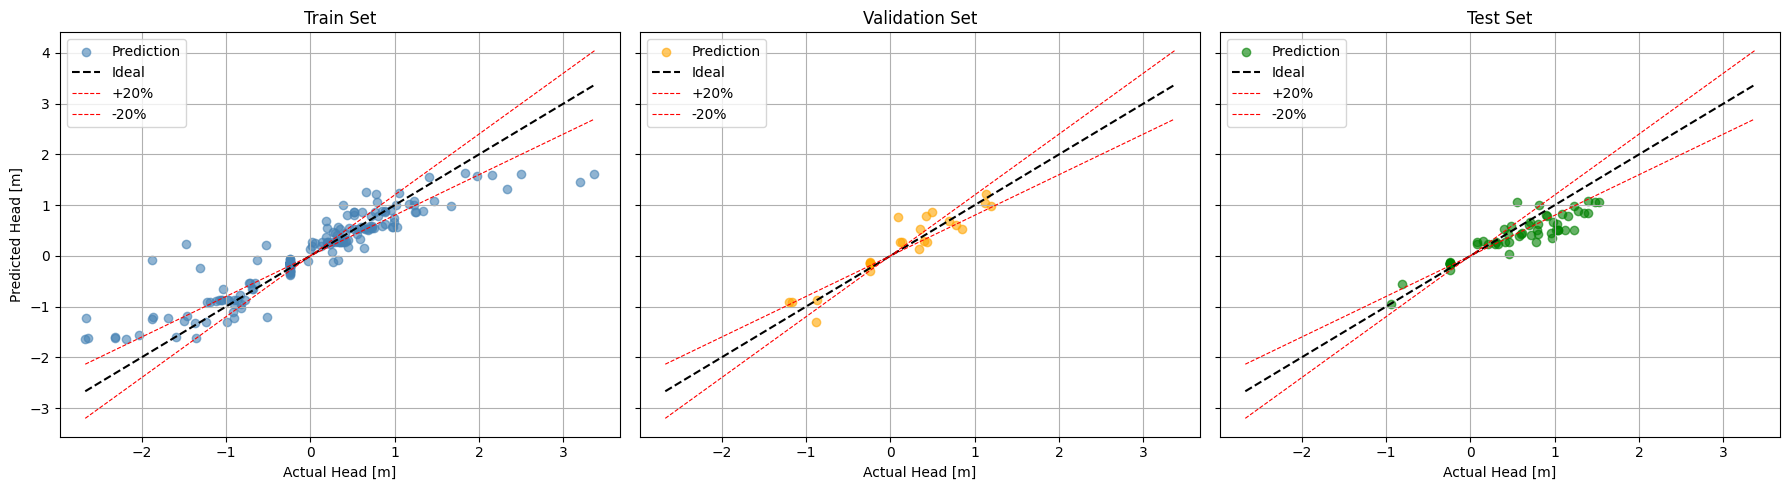

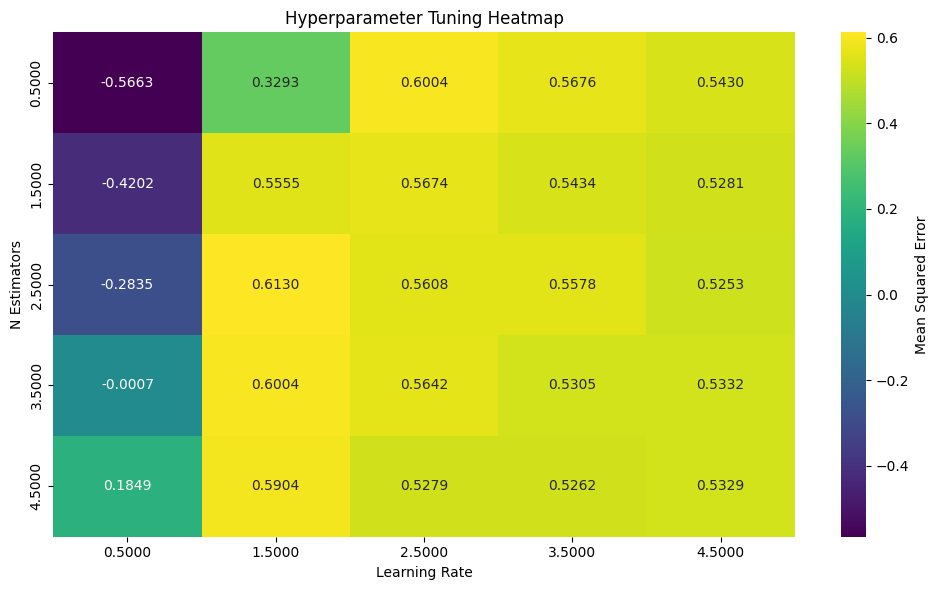

In [43]:
#Split and scaled new train set
Xtrain_scaled7, Xval_scaled7, Xtest_scaled7, ytrain_scaled7, yval_scaled7, ytest_scaled7, scalerx7, scalery7 = fun.splitandscale_byfluid(train_sets[6]
                                                                                                                                         , testdata_bepscaled, feature_cols, target_cols, val_size)

#Train XGBoost new train set (+2 fluids)
xgb_model7, xgb_score7 = fun.xgboost_with_cv(Xtrain_scaled7, ytrain_scaled7, Xval_scaled7, yval_scaled7,
                                             Xtest_scaled7, ytest_scaled7, param_dist, n_iter, cv_folds, img_name='no')
xgb_modelsGSi.append(xgb_model7)
xgb_scoresGSi.append(xgb_score7)

**Eight Iteration**

In [44]:
#Select the 2 fluids to simulate 
fluids_selected, update_pool8 = fun.greedy_sampling_inputs_outputs(xgb_model7, train_sets[6], update_pool7
                                                                  , scalerx7, feature_cols)
fluids_selected 

Selected 2 new candidates:
Remaining pool size: 2984


/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


,rho(kg/m3),k(Pa*s^n),n(-),FluidType,massflow_dim
2597,1005.115418,2.913886,0.434272,PowerLaw,1.544249
2738,1011.309240,2.272720,0.458250,PowerLaw,1.564699


In [45]:
#Load the results of the simulations of the selected fluids
file_path = "/Users/danielmorantes/Downloads/DatasetFinal.xlsx"
sheet_name = "GSiXGB"
GSiraw8 = fun.load_excel_data(file_path, sheet_name)

#BEP scaling og the raw selected fluids
entireGSi8, GSi_BEPscaled8 = fun.apply_bep_scaling(GSiraw8)
GSi_BEPscaled8.info()

 Loaded data with shape: (96, 11)
 Loaded Fluids: 16
Dropped columns: ['Liquid', 'Concentration', 'Flow Rate(GPM)', 'Flow Rate[m3/h]', 'Omega(rpm)']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   LiquidNo            74 non-null     int64  
 1   rho(kg/m3)          74 non-null     float64
 2   k(Pa*s^n)           74 non-null     float64
 3   n(-)                74 non-null     float64
 4   massflow_dim        74 non-null     float64
 5   torque_dim          74 non-null     float64
 6   hydraulicpower_dim  74 non-null     float64
 7   breakpower_dim      74 non-null     float64
 8   eff_dim             74 non-null     float64
 9   head_dim            74 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 5.9 KB


In [46]:
#Add to the original train set the GSi generated fluids 2 by 2
train_sets, list_fluids8 = fun.loop_add_fluids_in_order(bepscaled_initial_trainData, GSi_BEPscaled8)
train_sets[7] #Look for the eigth train set (Original + 16 fluids)

Iteration 1: New training set includes 35 unique fluids
Iteration 2: New training set includes 37 unique fluids
Iteration 3: New training set includes 39 unique fluids
Iteration 4: New training set includes 41 unique fluids
Iteration 5: New training set includes 43 unique fluids
Iteration 6: New training set includes 45 unique fluids
Iteration 7: New training set includes 47 unique fluids
Iteration 8: New training set includes 49 unique fluids


,LiquidNo,rho(kg/m3),k(Pa*s^n),n(-),massflow_dim,torque_dim,hydraulicpower_dim,breakpower_dim,eff_dim,head_dim
0,0,997.00000,0.00100,1.00000,0.000000,0.679632,0.000000,0.679633,0.000000,1.290569
1,0,997.00000,0.00100,1.00000,0.250000,0.724184,0.303160,0.724184,0.418623,1.212641
2,0,997.00000,0.00100,1.00000,0.500000,0.812492,0.582448,0.812492,0.716867,1.164897
3,0,997.00000,0.00100,1.00000,0.750000,0.913659,0.824483,0.913659,0.902397,1.099311
4,0,997.00000,0.00100,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...
210,48,1011.30924,2.27272,0.45825,0.250000,1.000000,1.000000,1.000000,0.550660,1.633525
211,48,1011.30924,2.27272,0.45825,0.500000,1.000000,1.000000,1.000000,0.471311,0.912072
212,48,1011.30924,2.27272,0.45825,0.750000,1.000000,1.000000,1.000000,0.993202,1.213819
213,48,1011.30924,2.27272,0.45825,0.980946,1.000000,1.000000,1.000000,0.986249,1.002598


Split completed: 196 train samples, 19 validation samples.
Test set size: 57 samples (FIXED TEST SET).
Features and target scaled.
Fitting 25 folds for each of 500 candidates, totalling 12500 fits
mse_train: 0.1120
r2_train: 0.8880
mse_val: 0.2309
r2_val: 0.7456
mse_test: 0.0774
r2_test: 0.7916
Best hyperparameters: {'subsample': 0.6, 'reg_lambda': 0, 'reg_alpha': 1, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 1.0}


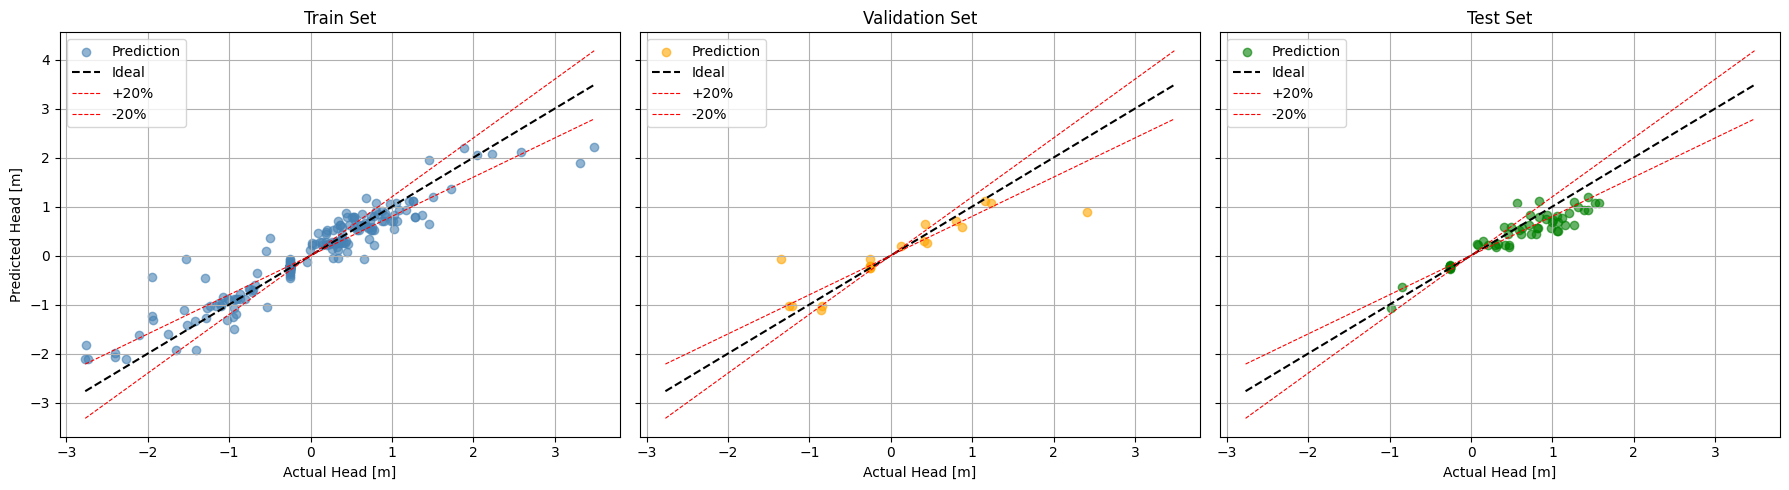

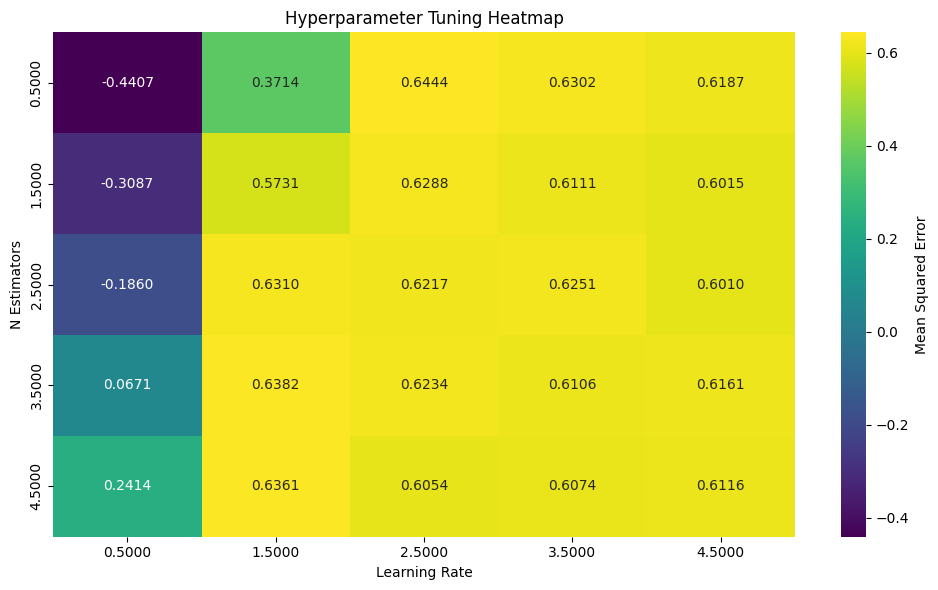

In [47]:
#Split and scaled new train set
Xtrain_scaled8, Xval_scaled8, Xtest_scaled8, ytrain_scaled8, yval_scaled8, ytest_scaled8, scalerx8, scalery8 = fun.splitandscale_byfluid(train_sets[7]
                                                                                                                                         , testdata_bepscaled, feature_cols, target_cols, val_size)

#Train XGBoost new train set (+2 fluids)
xgb_model8, xgb_score8 = fun.xgboost_with_cv(Xtrain_scaled8, ytrain_scaled8, Xval_scaled8, yval_scaled8,
                                             Xtest_scaled8, ytest_scaled8, param_dist, n_iter, cv_folds, img_name='no')
xgb_modelsGSi.append(xgb_model8)
xgb_scoresGSi.append(xgb_score8)

**Nineth Iteration**

In [48]:
#Select the 2 fluids to simulate 
fluids_selected, update_pool9 = fun.greedy_sampling_inputs_outputs(xgb_model8, train_sets[7], update_pool8
                                                                  , scalerx8, feature_cols)
fluids_selected 

Selected 2 new candidates:
Remaining pool size: 2982


/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


,rho(kg/m3),k(Pa*s^n),n(-),FluidType,massflow_dim
2030,1013.955034,10.404517,0.420689,PowerLaw,0.067158
2940,1007.290408,9.440947,0.545825,PowerLaw,0.025835


In [49]:
#Load the results of the simulations of the selected fluids
file_path = "/Users/danielmorantes/Downloads/DatasetFinal.xlsx"
sheet_name = "GSiXGB"
GSiraw9 = fun.load_excel_data(file_path, sheet_name)

#BEP scaling og the raw selected fluids
entireGSi9, GSi_BEPscaled9 = fun.apply_bep_scaling(GSiraw9)
GSi_BEPscaled9.info()

 Loaded data with shape: (108, 11)
 Loaded Fluids: 18
Dropped columns: ['Liquid', 'Concentration', 'Flow Rate(GPM)', 'Flow Rate[m3/h]', 'Omega(rpm)']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   LiquidNo            80 non-null     int64  
 1   rho(kg/m3)          80 non-null     float64
 2   k(Pa*s^n)           80 non-null     float64
 3   n(-)                80 non-null     float64
 4   massflow_dim        80 non-null     float64
 5   torque_dim          80 non-null     float64
 6   hydraulicpower_dim  80 non-null     float64
 7   breakpower_dim      80 non-null     float64
 8   eff_dim             80 non-null     float64
 9   head_dim            80 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 6.4 KB


In [57]:
#Add to the original train set the GSi generated fluids 2 by 2
train_sets, list_fluids9 = fun.loop_add_fluids_in_order(bepscaled_initial_trainData, GSi_BEPscaled9)
#train_sets[8] #Look for the nineth train set (Original + 18 fluids)
train_sets[8]

Iteration 1: New training set includes 35 unique fluids
Iteration 2: New training set includes 37 unique fluids
Iteration 3: New training set includes 39 unique fluids
Iteration 4: New training set includes 41 unique fluids
Iteration 5: New training set includes 43 unique fluids
Iteration 6: New training set includes 45 unique fluids
Iteration 7: New training set includes 47 unique fluids
Iteration 8: New training set includes 49 unique fluids
Iteration 9: New training set includes 51 unique fluids


,LiquidNo,rho(kg/m3),k(Pa*s^n),n(-),massflow_dim,torque_dim,hydraulicpower_dim,breakpower_dim,eff_dim,head_dim
0,0,997.000000,0.001000,1.000000,0.000000,0.679632,0.000000,0.679633,0.000000,1.290569
1,0,997.000000,0.001000,1.000000,0.250000,0.724184,0.303160,0.724184,0.418623,1.212641
2,0,997.000000,0.001000,1.000000,0.500000,0.812492,0.582448,0.812492,0.716867,1.164897
3,0,997.000000,0.001000,1.000000,0.750000,0.913659,0.824483,0.913659,0.902397,1.099311
4,0,997.000000,0.001000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...
216,49,1013.955034,10.404517,0.420689,0.666667,1.000000,1.000000,1.000000,0.910547,1.235561
217,49,1013.955034,10.404517,0.420689,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
218,49,1013.955034,10.404517,0.420689,1.333333,1.000000,1.000000,1.000000,0.833403,0.660372
219,50,1007.290408,9.440947,0.545825,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Split completed: 201 train samples, 20 validation samples.
Test set size: 57 samples (FIXED TEST SET).
Features and target scaled.
Fitting 25 folds for each of 500 candidates, totalling 12500 fits


mse_train: 0.3181
r2_train: 0.6819
mse_val: 1.7104
r2_val: 0.2560
mse_test: 0.1123
r2_test: 0.7210
Best hyperparameters: {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 1.0}


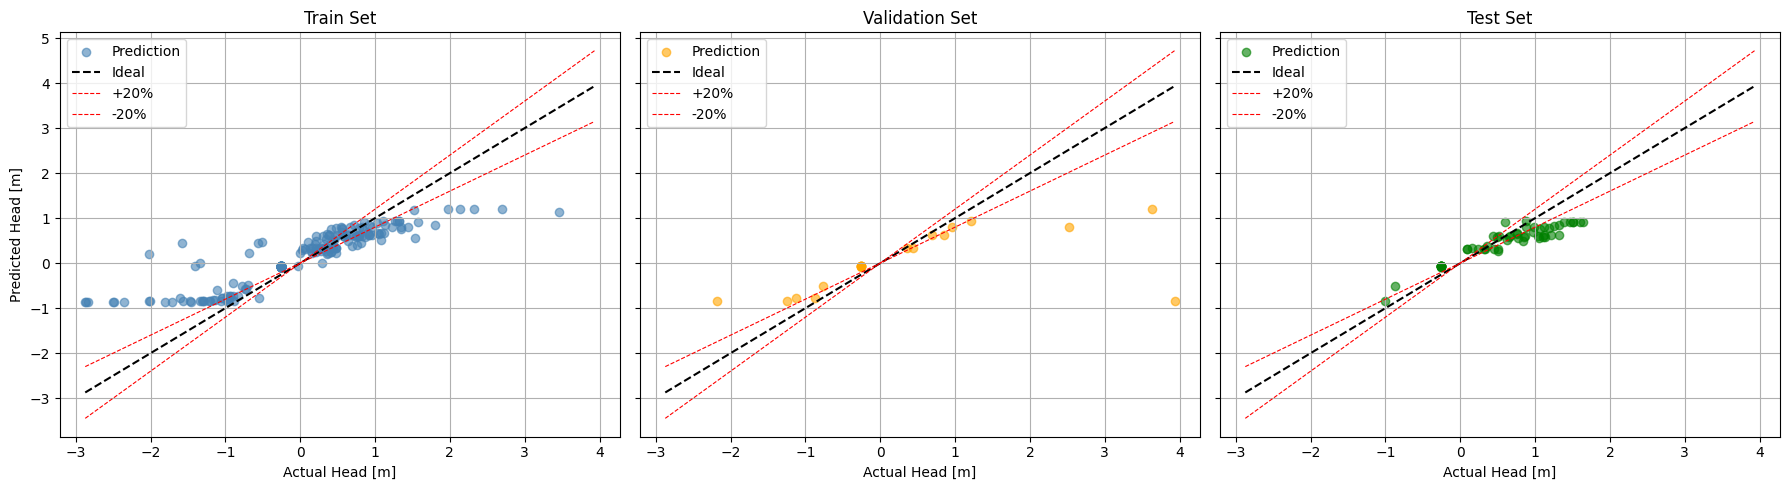

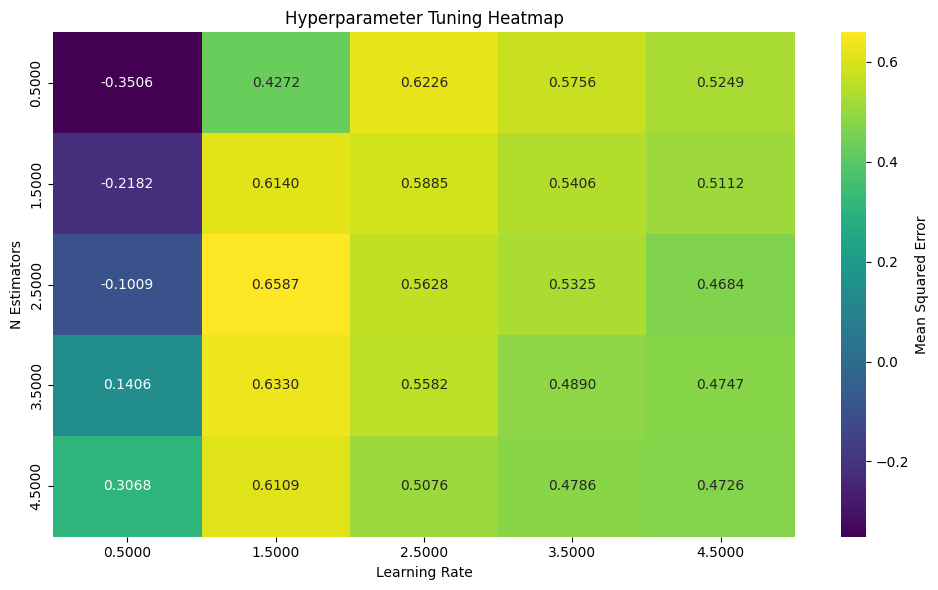

In [56]:
#Split and scaled new train set
Xtrain_scaled9, Xval_scaled9, Xtest_scaled9, ytrain_scaled9, yval_scaled9, ytest_scaled9, scalerx9, scalery9 = fun.splitandscale_byfluid(train_sets[8]
                                                                                                                                         , testdata_bepscaled, feature_cols, target_cols, val_size)

#Train XGBoost new train set (+2 fluids)
xgb_model9, xgb_score9 = fun.xgboost_with_cv(Xtrain_scaled9, ytrain_scaled9, Xval_scaled9, yval_scaled9,
                                             Xtest_scaled9, ytest_scaled9, param_dist, n_iter, cv_folds, img_name='no')
xgb_modelsGSi.append(xgb_model9)
xgb_scoresGSi.append(xgb_score9)

**Tenth Iteration**

In [58]:
#Select the 2 fluids to simulate 
fluids_selected, update_pool10 = fun.greedy_sampling_inputs_outputs(xgb_model9, train_sets[8], update_pool9
                                                                  , scalerx9, feature_cols)
fluids_selected 

Selected 2 new candidates:
Remaining pool size: 2980


/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


,rho(kg/m3),k(Pa*s^n),n(-),FluidType,massflow_dim
2577,1005.336652,10.768227,0.231085,PowerLaw,0.010190
2239,1016.144379,0.859574,0.565163,PowerLaw,0.034531


In [5]:
#Load the results of the simulations of the selected fluids
file_path = "/Users/danielmorantes/Downloads/DatasetFinal.xlsx"
sheet_name = "GSiXGB"
GSiraw10 = fun.load_excel_data(file_path, sheet_name)

#BEP scaling og the raw selected fluids
entireGSi10, GSi_BEPscaled10 = fun.apply_bep_scaling(GSiraw10)
GSi_BEPscaled10.info()

 Loaded data with shape: (120, 11)
 Loaded Fluids: 20
Dropped columns: ['Liquid', 'Concentration', 'Flow Rate(GPM)', 'Flow Rate[m3/h]', 'Omega(rpm)']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89 entries, 0 to 88
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   LiquidNo            89 non-null     int64  
 1   rho(kg/m3)          89 non-null     float64
 2   k(Pa*s^n)           89 non-null     float64
 3   n(-)                89 non-null     float64
 4   massflow_dim        89 non-null     float64
 5   torque_dim          89 non-null     float64
 6   hydraulicpower_dim  89 non-null     float64
 7   breakpower_dim      89 non-null     float64
 8   eff_dim             89 non-null     float64
 9   head_dim            89 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 7.1 KB


In [6]:
#Add to the original train set the GSi generated fluids 2 by 2
train_sets, list_fluids10 = fun.loop_add_fluids_in_order(bepscaled_initial_trainData, GSi_BEPscaled10)
train_sets[9] #Look for the tenth train set (Original + 20 fluids)

Iteration 1: New training set includes 35 unique fluids
Iteration 2: New training set includes 37 unique fluids
Iteration 3: New training set includes 39 unique fluids
Iteration 4: New training set includes 41 unique fluids
Iteration 5: New training set includes 43 unique fluids
Iteration 6: New training set includes 45 unique fluids
Iteration 7: New training set includes 47 unique fluids
Iteration 8: New training set includes 49 unique fluids
Iteration 9: New training set includes 51 unique fluids
Iteration 10: New training set includes 53 unique fluids


,LiquidNo,rho(kg/m3),k(Pa*s^n),n(-),massflow_dim,torque_dim,hydraulicpower_dim,breakpower_dim,eff_dim,head_dim
0,0,997.000000,0.001000,1.000000,0.000000,0.679632,0.000000,0.679633,0.000000,1.290569
1,0,997.000000,0.001000,1.000000,0.250000,0.724184,0.303160,0.724184,0.418623,1.212641
2,0,997.000000,0.001000,1.000000,0.500000,0.812492,0.582448,0.812492,0.716867,1.164897
3,0,997.000000,0.001000,1.000000,0.750000,0.913659,0.824483,0.913659,0.902397,1.099311
4,0,997.000000,0.001000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...
225,51,1005.336652,10.768227,0.231085,1.333333,1.000000,1.000000,1.000000,0.872933,0.762356
226,52,1016.144379,0.859574,0.565163,0.333333,1.000000,1.000000,1.000000,0.502237,1.189670
227,52,1016.144379,0.859574,0.565163,0.666667,1.000000,1.000000,1.000000,0.845898,1.139776
228,52,1016.144379,0.859574,0.565163,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Split completed: 202 train samples, 28 validation samples.
Test set size: 57 samples (FIXED TEST SET).
Features and target scaled.
Fitting 25 folds for each of 500 candidates, totalling 12500 fits


/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/numpy/ma/core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


mse_train: 0.4005
r2_train: 0.5995
mse_val: 0.0944
r2_val: 0.7767
mse_test: 0.0804
r2_test: 0.7571
Best hyperparameters: {'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 0.5, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 2, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 1.0}


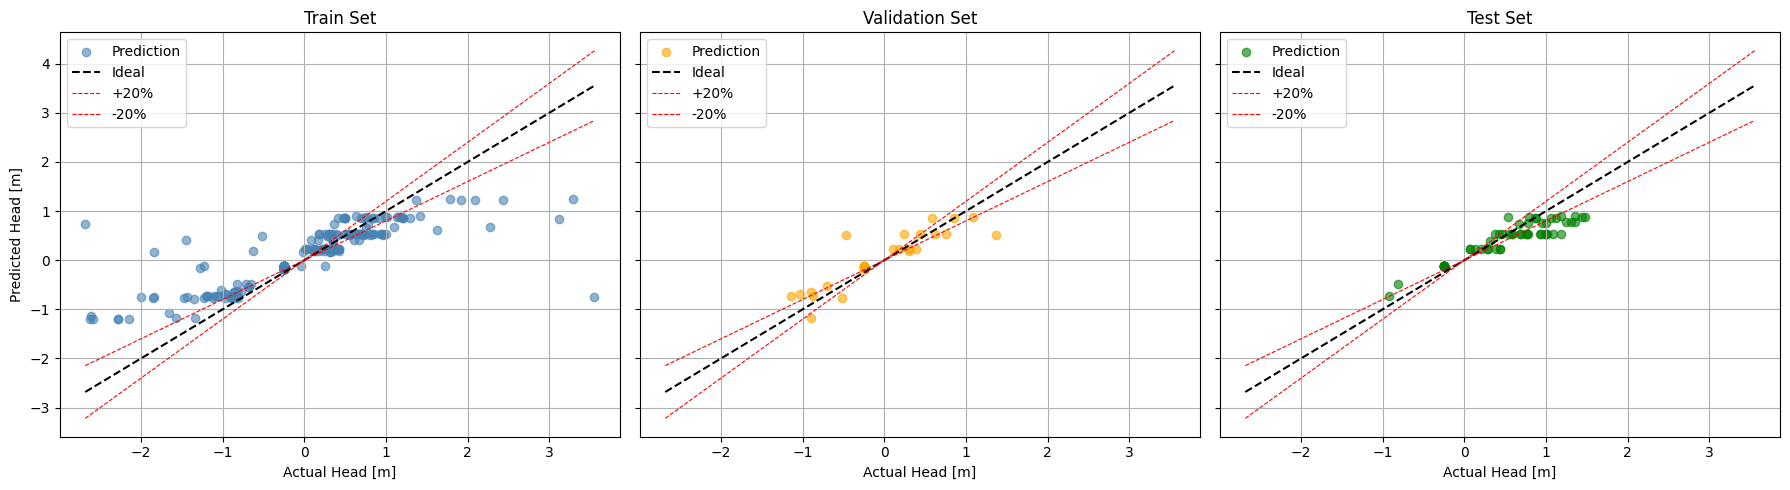

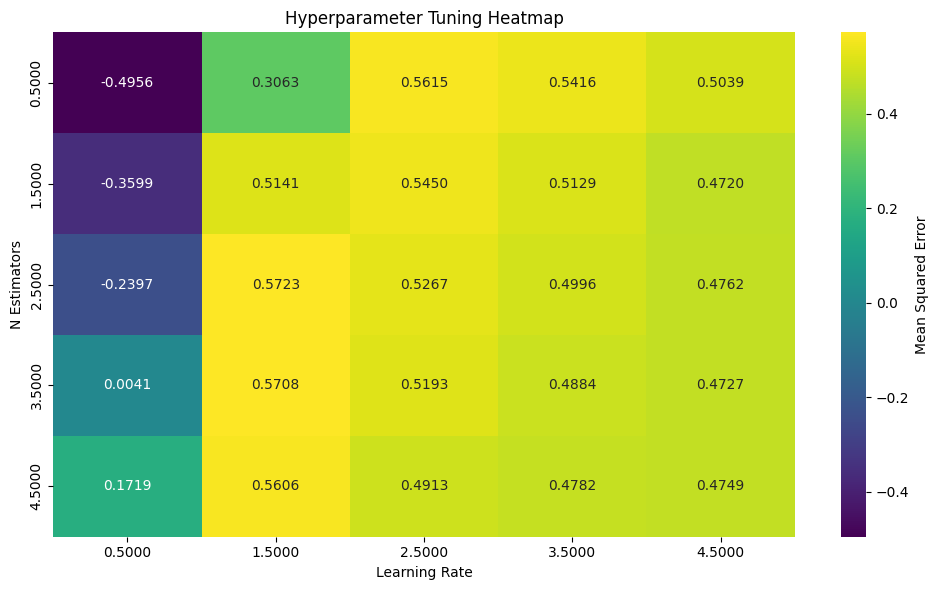

In [61]:
#Split and scaled new train set
Xtrain_scaled10, Xval_scaled10, Xtest_scaled10, ytrain_scaled10, yval_scaled10, ytest_scaled10, scalerx10, scalery10 = fun.splitandscale_byfluid(train_sets[9]
                                                                                                                                         , testdata_bepscaled, feature_cols, target_cols, val_size)

#Train XGBoost new train set (+2 fluids)
xgb_model10, xgb_score10 = fun.xgboost_with_cv(Xtrain_scaled10, ytrain_scaled10, Xval_scaled10, yval_scaled10,
                                             Xtest_scaled10, ytest_scaled10, param_dist, n_iter, cv_folds, img_name='no')
xgb_modelsGSi.append(xgb_model10)
xgb_scoresGSi.append(xgb_score10)

In [ ]:
#Retrain XGBoost models with the selected fluids to obtain the final MAE and EV
val_size = 0.1
Xtrain_setsXGB, ytrain_setsXGB, Xval_setsXGB, yval_setsXGB, Xtest_setsXGB, ytest_setsXGB = fun.split_scale_by_fluid_multiple_trainsets(train_sets, testdata_bepscaled, feature_cols, target_cols, val_size)
img_name = 'no'
xgb_models, xgb_scores = fun.train_multiple_XGBoost(Xtrain_setsXGB, ytrain_setsXGB, Xval_setsXGB, yval_setsXGB
                                                        ,Xtest_setsXGB, ytest_setsXGB, param_dist, n_iter, cv_folds, img_name)

Split completed: 133 train samples, 17 validation samples.
Test set size: 57 samples (FIXED TEST SET).
Features and target scaled.
Split completed: 141 train samples, 15 validation samples.
Test set size: 57 samples (FIXED TEST SET).
Features and target scaled.
Split completed: 146 train samples, 22 validation samples.
Test set size: 57 samples (FIXED TEST SET).
Features and target scaled.
Split completed: 153 train samples, 25 validation samples.
Test set size: 57 samples (FIXED TEST SET).
Features and target scaled.
Split completed: 160 train samples, 25 validation samples.
Test set size: 57 samples (FIXED TEST SET).
Features and target scaled.
Split completed: 170 train samples, 24 validation samples.
Test set size: 57 samples (FIXED TEST SET).
Features and target scaled.
Split completed: 182 train samples, 24 validation samples.
Test set size: 57 samples (FIXED TEST SET).
Features and target scaled.
Split completed: 196 train samples, 19 validation samples.
Test set size: 57 sample

# RESULTS

**Results Greedy Sampling on the Inputs and Outputs XGBoost**

In [83]:
xgbf = []
xgbf.append(xgb_score1)
xgbf.append(xgb_score2)
xgbf.append(xgb_score3)
xgbf.append(xgb_score4)
xgbf.append(xgb_score5)
xgbf.append(xgb_score6)
xgbf.append(xgb_score7)
xgbf.append(xgb_score8)
xgbf.append(xgb_score9)
xgbf.append(xgb_score10)

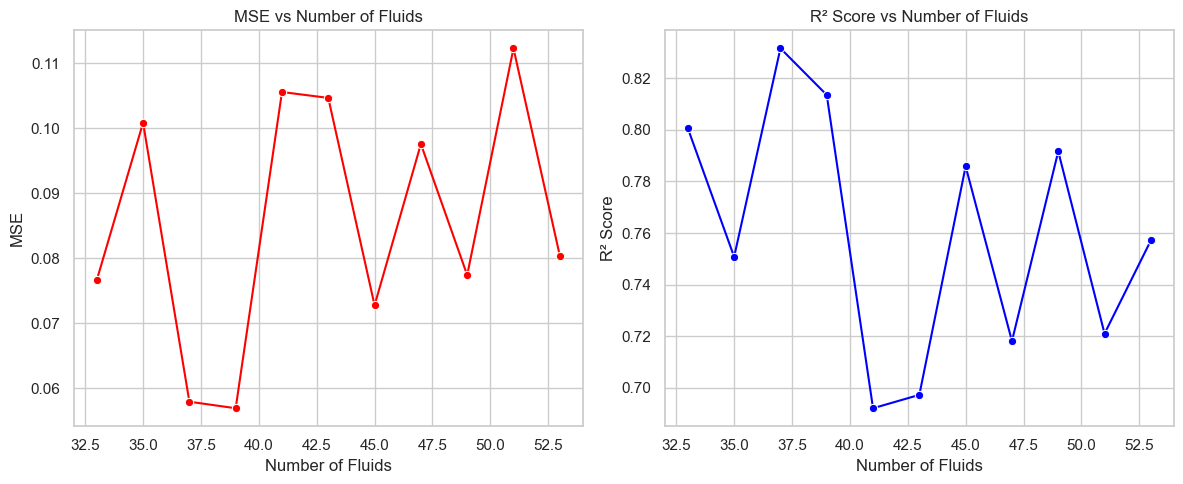

XGBscoresiGS saved in artifacts


In [86]:
#Track performance while adding new fluids
fun.plot_testmetrics_vs_fluids(intresultsxgb, xgbf, list_fluids10)
fun.save_object(xgbf, 'XGBscoresiGS')